In [20]:
# 导入必要库

import numpy as np  # 数值计算与数组操作
from sklearn.base import BaseEstimator, ClassifierMixin  # 让自定义模型兼容 sklearn 接口
from sklearn.preprocessing import StandardScaler  # 对特征做标准化（均值0，方差1）
from sklearn.model_selection import train_test_split  # 划分训练集和测试集
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix  # 分类评估指标与混淆矩阵
import matplotlib.pyplot as plt  # 基础绘图库
from matplotlib import font_manager  # 字体管理，用于配置中文显示

try:
    import seaborn as sns  # 统计可视化库，常用于更美观的图表
except ModuleNotFoundError:
    sns = None
    print('未检测到 seaborn,将使用 matplotlib 绘制混淆矩阵。')

def setup_chinese_font():
    """配置 matplotlib 中文字体，避免中文标签显示为方块。"""
    candidate_fonts = [
        'Microsoft YaHei', 'SimHei', 'SimSun',
        'Noto Sans CJK SC', 'WenQuanYi Micro Hei', 'Arial Unicode MS'
    ]
    available_fonts = {f.name for f in font_manager.fontManager.ttflist}

    for font_name in candidate_fonts:
        if font_name in available_fonts:
            plt.rcParams['font.sans-serif'] = [font_name] + plt.rcParams.get('font.sans-serif', [])
            plt.rcParams['axes.unicode_minus'] = False
            print(f'已启用中文字体: {font_name}')
            return font_name

    plt.rcParams['axes.unicode_minus'] = False
    print('未找到常见中文字体，中文可能无法正常显示。可安装微软雅黑或黑体后重启内核。')
    return None

setup_chinese_font()
print('所有库导入完成!')


未检测到 seaborn,将使用 matplotlib 绘制混淆矩阵。
已启用中文字体: Microsoft YaHei
所有库导入完成!


In [21]:
class LogisticRegressionFromScratch(BaseEstimator, ClassifierMixin):
    """从零实现逻辑回归"""
    
    def __init__(self, learning_rate=0.01, n_iterations=1000, 
                 regularization='l2', lambda_=0.01, verbose=False):
        """
        参数:
        learning_rate: 学习率
        n_iterations: 迭代次数
        regularization: 正则化类型 ('l1', 'l2', 'none')
        lambda_: 正则化强度
        verbose: 是否打印训练过程
        """
        self.lr = learning_rate
        self.n_iters = n_iterations
        self.reg = regularization
        self.lambda_ = lambda_
        self.verbose = verbose
        self.weights = None
        self.bias = None
        self.loss_history = []
        
    def _sigmoid(self, z):
        """Sigmoid function with numerical stability."""
        # 使用 clip 限制 z 的范围，避免 exp 计算溢出
        z = np.clip(z, -500, 500)  # 将 z 裁剪到 [-500, 500]
        return 1 / (1 + np.exp(-z))
    
    def _compute_loss(self, y_true, y_pred):
        """Compute cross-entropy loss plus regularization."""
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)  # 避免概率为 0 或 1，防止 log(0)和 log(1) 的出现
        
        # 单样本交叉熵: L_i = -[y_i*log(p_i) + (1-y_i)*log(1-p_i)]
        # 多样本平均交叉熵: J = -(1/m) * Σ_i [y_i*log(p_i) + (1-y_i)*log(1-p_i)]
        # 当前实现使用 np.mean，对全部样本损失取平均
        ce_loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        
        # 正则化项
        reg_loss = 0
        if self.reg == 'l2' and self.weights is not None:
            reg_loss = (self.lambda_ / 2) * np.sum(self.weights**2)    #J(w,b)+(_lambda/2)*np.sum(W**2)
        elif self.reg == 'l1' and self.weights is not None:
            reg_loss = self.lambda_ * np.sum(np.abs(self.weights))     #J(w,b)+(_lambda)*np.sum(W)
            
        return ce_loss + reg_loss
    
    def fit(self, X, y):
        """训练逻辑回归模型"""
        n_samples, n_features = X.shape
        
        # 初始化参数
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # 梯度下降
        for i in range(self.n_iters):
            # 前向传播
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(linear_model)
            
            # 计算损失
            loss = self._compute_loss(y, y_pred)
            self.loss_history.append(loss)
            
            # 计算梯度
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)
            
            # 添加正则化梯度
            if self.reg == 'l2':
                dw += self.lambda_ * self.weights
            elif self.reg == 'l1':
                dw += self.lambda_ * np.sign(self.weights)
            
            # 更新参数
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            # 打印进度
            if self.verbose and i % 100 == 0:
                print(f"Iteration {i}: Loss = {loss:.4f}")
                
        return self
    
    def predict_proba(self, X):
        """预测概率"""
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)
    
    def predict(self, X, threshold=0.5):
        """预测类别"""
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)  # 按阈值比较后将 True/False 转为 1/0 类别标签
    
    def decision_function(self, X):
        """决策函数值 (w·x + b)"""
        return np.dot(X, self.weights) + self.bias

In [22]:
def generate_logistic_data(n_samples=300, noise=0.1, random_state=42):
    """生成二分类数据"""
    np.random.seed(random_state)
    
    # 生成两个类别的数据
    n_class = n_samples // 2
    
    # 类别0: 均值[-1, -1]，协方差矩阵
    mean0 = [-1, -1]
    cov0 = [[1, 0.5], [0.5, 1]]
    X0 = np.random.multivariate_normal(mean0, cov0, n_class)  # 按给定均值和协方差采样 n_class 个二维高斯点（类别0）
    y0 = np.zeros(n_class)
    
    # 类别1: 均值[1, 1]，协方差矩阵
    mean1 = [1, 1]
    cov1 = [[1, -0.3], [-0.3, 1]]
    X1 = np.random.multivariate_normal(mean1, cov1, n_class)  # 按给定均值和协方差采样 n_class 个二维高斯点（类别1）
    y1 = np.ones(n_class)
    
    # 合并数据
    X = np.vstack([X0, X1])
    y = np.hstack([y0, y1])
    
    # 添加噪声
    X += np.random.randn(*X.shape) * noise  # 生成与 X 同形状的高斯噪声，按 noise 缩放后叠加到特征上
    
    # 打乱数据
    indices = np.random.permutation(n_samples)  # 生成 0~n_samples-1 的随机排列索引，用于打乱样本顺序
    return X[indices], y[indices]


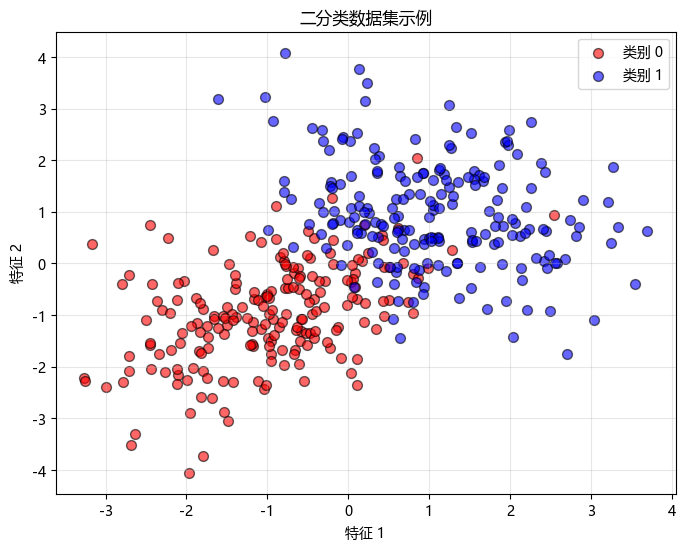

训练集大小: (280, 2), 测试集大小: (120, 2)
类别分布 - 训练集: [140 140]
类别分布 - 测试集: [60 60]
Iteration 0: Loss = 0.6931
Iteration 100: Loss = 0.4053
Iteration 200: Loss = 0.4045
Iteration 300: Loss = 0.4045
Iteration 400: Loss = 0.4045
Iteration 500: Loss = 0.4045
Iteration 600: Loss = 0.4045
Iteration 700: Loss = 0.4045
Iteration 800: Loss = 0.4045
Iteration 900: Loss = 0.4045
Iteration 1000: Loss = 0.4045
Iteration 1100: Loss = 0.4045
Iteration 1200: Loss = 0.4045
Iteration 1300: Loss = 0.4045
Iteration 1400: Loss = 0.4045
Iteration 1500: Loss = 0.4045
Iteration 1600: Loss = 0.4045
Iteration 1700: Loss = 0.4045
Iteration 1800: Loss = 0.4045
Iteration 1900: Loss = 0.4045


In [23]:
# 生成并可视化数据
X_data, y_data = generate_logistic_data(n_samples=400, noise=0.2)

plt.figure(figsize=(8, 6))
plt.scatter(X_data[y_data==0, 0], X_data[y_data==0, 1], 
           color='red', alpha=0.6, s=50, label='类别 0', edgecolors='k')
plt.scatter(X_data[y_data==1, 0], X_data[y_data==1, 1], 
           color='blue', alpha=0.6, s=50, label='类别 1', edgecolors='k')
plt.xlabel('特征 1')
plt.ylabel('特征 2')
plt.title('二分类数据集示例')
plt.legend()  # 显示图例，图例文本来自前面绘图语句的 label
plt.grid(True, alpha=0.3)
plt.show()

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_data, test_size=0.3, random_state=42, stratify=y_data
)

print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")
print(f"类别分布 - 训练集: {np.bincount(y_train.astype(int))}")
print(f"类别分布 - 测试集: {np.bincount(y_test.astype(int))}")

# 训练模型
model = LogisticRegressionFromScratch(
    learning_rate=0.1,
    n_iterations=2000,
    regularization='l2',
    lambda_=0.1,
    verbose=True
)

model.fit(X_train, y_train)

# 预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)



训练集评估结果
准确率 (Accuracy): 0.9286
精确率 (Precision): 0.9110
召回率 (Recall): 0.9500
F1分数: 0.9301


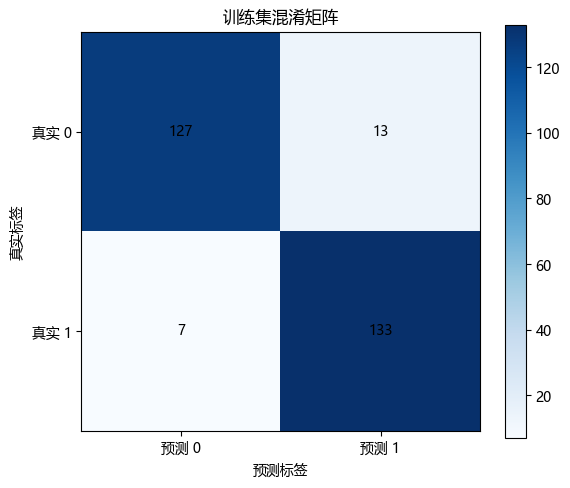


测试集评估结果
准确率 (Accuracy): 0.9167
精确率 (Precision): 0.8788
召回率 (Recall): 0.9667
F1分数: 0.9206
AUC分数: 0.9800


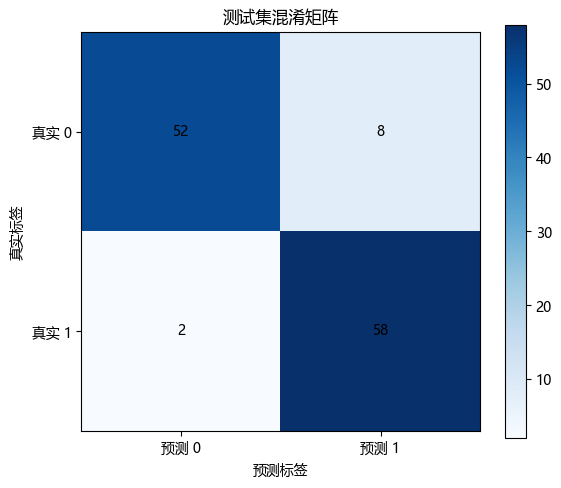

In [ ]:
def evaluate_classification(y_true, y_pred, y_proba=None, set_name="测试集"):
    """综合评估分类模型。"""
    print(f"\n{'='*60}")
    print(f"{set_name}评估结果")
    print(f"{'='*60}")

    # 基础指标
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"准确率 (Accuracy): {accuracy:.4f}")
    print(f"精确率 (Precision): {precision:.4f}")
    print(f"召回率 (Recall): {recall:.4f}")
    print(f"F1分数: {f1:.4f}")

    # 如果有概率预测，计算 AUC
    auc = None
    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        print(f"AUC分数: {auc:.4f}")

    # 混淆矩阵
    cm = confusion_matrix(y_true, y_pred)  # 计算混淆矩阵：统计 TN/FP/FN/TP 的数量

    plt.figure(figsize=(6, 5))
    if sns is not None:
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['预测 0', '预测 1'],
            yticklabels=['真实 0', '真实 1']
        )
    else:
        # seaborn 不可用时的回退绘图，避免中断
        plt.imshow(cm, cmap='Blues')
        plt.colorbar()       #在图旁边添加颜色条，说明颜色深浅对应的数值范围
        plt.xticks([0, 1], ['预测 0', '预测 1'])
        plt.yticks([0, 1], ['真实 0', '真实 1'])
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

    plt.title(f'{set_name}混淆矩阵')
    plt.ylabel('真实标签')
    plt.xlabel('预测标签')
    plt.tight_layout()      #自动调整子图和文字
    plt.show()

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
    }

# 评估训练集和测试集
train_metrics = evaluate_classification(y_train, y_train_pred, set_name="训练集")
test_metrics = evaluate_classification(y_test, y_test_pred, y_test_proba, set_name="测试集")


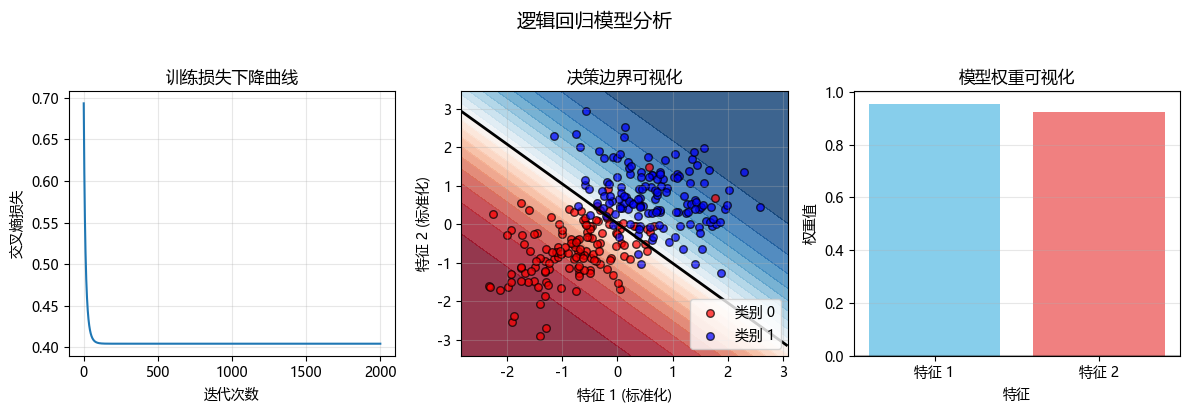


模型参数总结:
权重 w = [0.9543, 0.9241]
偏置 b = -0.0189
决策边界方程: 0.9543*x1 + 0.9241*x2 + -0.0189 = 0


In [25]:
# 可视化训练过程
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(model.loss_history)
plt.xlabel('迭代次数')
plt.ylabel('交叉熵损失')
plt.title('训练损失下降曲线')
plt.grid(True, alpha=0.3)

# 可视化决策边界
plt.subplot(1, 3, 2)
# 创建网格点
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),  # 生成二维网格坐标，便于在整个平面上批量预测
                     np.linspace(y_min, y_max, 200))

# 预测网格点的概率
Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 绘制决策边界和概率等高线
plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.8)  # 填充等高线图：用颜色表示不同区域的预测概率
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)  # 绘制 p=0.5 等高线，即二分类决策边界

# 绘制数据点
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], 
           color='red', alpha=0.7, s=30, label='类别 0', edgecolors='k')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], 
           color='blue', alpha=0.7, s=30, label='类别 1', edgecolors='k')
plt.xlabel('特征 1 (标准化)')
plt.ylabel('特征 2 (标准化)')
plt.title('决策边界可视化')
plt.legend()  # 显示图例，图例文本来自前面绘图语句的 label
plt.grid(True, alpha=0.3)

# 权重可视化
plt.subplot(1, 3, 3)
features = ['特征 1', '特征 2']
weights = model.weights
plt.bar(features, weights, color=['skyblue', 'lightcoral'])
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('特征')
plt.ylabel('权重值')
plt.title('模型权重可视化')
plt.grid(True, alpha=0.3, axis='y')

plt.suptitle('逻辑回归模型分析', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n模型参数总结:")
print(f"权重 w = [{model.weights[0]:.4f}, {model.weights[1]:.4f}]")
print(f"偏置 b = {model.bias:.4f}")
print(f"决策边界方程: {model.weights[0]:.4f}*x1 + {model.weights[1]:.4f}*x2 + {model.bias:.4f} = 0")